<a href="https://colab.research.google.com/github/LucasZanellaClemente/Dynamic-Programming/blob/main/Dynamic_Programing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Treino

[[('2026-03-26 07:45',
   'coleta',
   {'cidade': 'Fortaleza', 'peso_kg': 45, 'urgencia': 'alta'}),
  ('2026-03-26 12:30',
   'entrega',
   {'cidade': 'Natal', 'peso_kg': 45, 'urgencia': 'alta'})],
 [('2026-03-26 09:00',
   'coleta',
   {'cidade': 'Manaus', 'peso_kg': 60, 'urgencia': 'media'}),
  ('2026-03-26 15:00',
   'entrega',
   {'cidade': 'Belém', 'peso_kg': 60, 'urgencia': 'media'})],
 [('2026-03-26 06:00',
   'coleta',
   {'cidade': 'Rio de Janeiro', 'peso_kg': 80, 'urgencia': 'baixa'}),
  ('2026-03-26 09:30',
   'hub',
   {'cidade': 'Volta Redonda', 'peso_kg': 80, 'urgencia': 'baixa'}),
  ('2026-03-26 13:00',
   'entrega',
   {'cidade': 'Belo Horizonte', 'peso_kg': 80, 'urgencia': 'baixa'})],
 [('2026-03-26 07:00',
   'coleta',
   {'cidade': 'São Paulo', 'peso_kg': 150, 'urgencia': 'alta'}),
  ('2026-03-26 10:00',
   'hub',
   {'cidade': 'Campinas', 'peso_kg': 150, 'urgencia': 'alta'}),
  ('2026-03-26 14:00',
   'entrega',
   {'cidade': 'Ribeirão Preto', 'peso_kg': 150, 'urgen

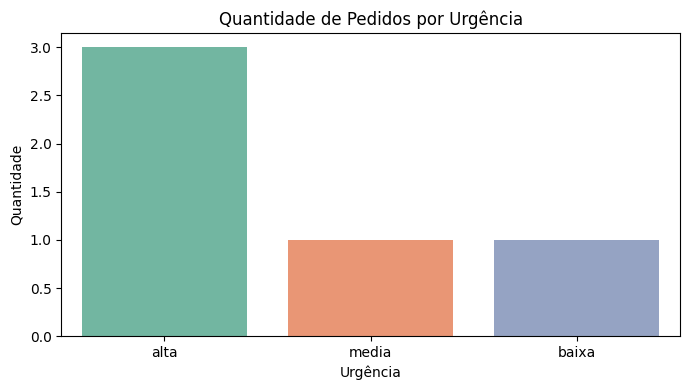

/tmp/ipykernel_2706/3752631069.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peso_cidade, x='cidade_origem', y='peso_kg', palette='Blues_d')


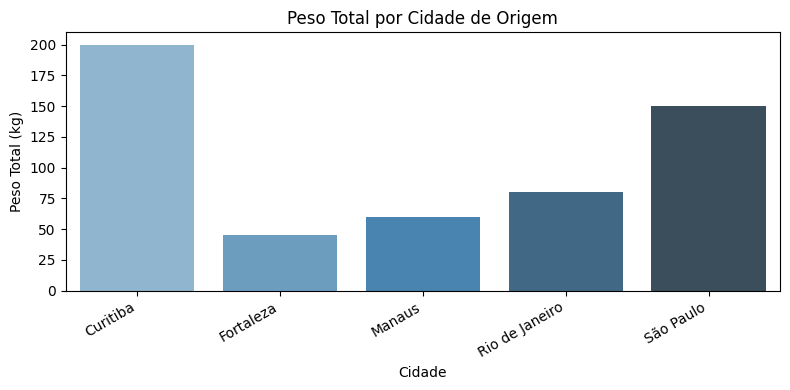

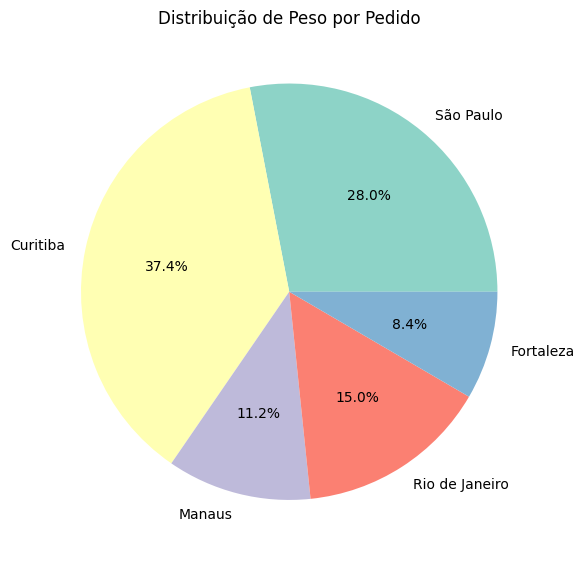

In [6]:

import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint
from collections import deque
import pandas as pd


pedidos = [
    [
        ("2026-03-26 07:00", "coleta",  {"cidade": "São Paulo",      "peso_kg": 150, "urgencia": "alta"}),
        ("2026-03-26 10:00", "hub",     {"cidade": "Campinas",       "peso_kg": 150, "urgencia": "alta"}),
        ("2026-03-26 14:00", "entrega", {"cidade": "Ribeirão Preto", "peso_kg": 150, "urgencia": "alta"}),
    ],
    [
        ("2026-03-26 08:30", "coleta",  {"cidade": "Curitiba",  "peso_kg": 200, "urgencia": "alta"}),
        ("2026-03-26 12:00", "hub",     {"cidade": "Londrina",  "peso_kg": 200, "urgencia": "alta"}),
        ("2026-03-26 17:00", "entrega", {"cidade": "São Paulo", "peso_kg": 200, "urgencia": "alta"}),
    ],
    [
        ("2026-03-26 09:00", "coleta",  {"cidade": "Manaus", "peso_kg": 60, "urgencia": "media"}),
        ("2026-03-26 15:00", "entrega", {"cidade": "Belém",  "peso_kg": 60, "urgencia": "media"}),
    ],
    [
        ("2026-03-26 06:00", "coleta",  {"cidade": "Rio de Janeiro", "peso_kg": 80, "urgencia": "baixa"}),
        ("2026-03-26 09:30", "hub",     {"cidade": "Volta Redonda",  "peso_kg": 80, "urgencia": "baixa"}),
        ("2026-03-26 13:00", "entrega", {"cidade": "Belo Horizonte", "peso_kg": 80, "urgencia": "baixa"}),
    ],
    [
        ("2026-03-26 07:45", "coleta",  {"cidade": "Fortaleza", "peso_kg": 45, "urgencia": "alta"}),
        ("2026-03-26 12:30", "entrega", {"cidade": "Natal",     "peso_kg": 45, "urgencia": "alta"}),
    ],
]

# REMOVIDO: pedidos = []  ← era o vilão

pedidos_ordenados = sorted(pedidos, key=lambda x: x[0][2]['peso_kg'])
pprint(pedidos_ordenados)


def organizar_fila(pedidos, fila):
    if len(pedidos) == 0:
        return fila

    item = pedidos[0]

    if item[0][2]['urgencia'] == "alta":
        fila.appendleft(item)
    else:
        fila.append(item)  # media e baixa vão pro final

    return organizar_fila(pedidos[1:], fila)  # ← fora do for, correto


fila = deque()
resultado = organizar_fila(pedidos, fila)
pprint(resultado)


dados = []
for pedido in pedidos:
    dados.append({
        "urgencia":      pedido[0][2]['urgencia'],
        "peso_kg":       pedido[0][2]['peso_kg'],
        "cidade_origem": pedido[0][2]['cidade'],
    })

df = pd.DataFrame(dados)
print(df)

# graficos
urgencia_count = df['urgencia'].value_counts().reset_index()
urgencia_count.columns = ['urgencia', 'quantidade']

peso_cidade = df.groupby('cidade_origem')['peso_kg'].sum().reset_index()

# 1 - Quantidade de pedidos por urgência
plt.figure(figsize=(7, 4))
sns.barplot(
    data=urgencia_count,
    x='urgencia',
    y='quantidade',
    hue='urgencia',    # <--- Adicione isso
    palette='Set2',
    legend=False       # <--- Adicione isso para remover a legenda lateral
)
plt.title('Quantidade de Pedidos por Urgência')
plt.xlabel('Urgência')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

# 2 - Peso total por cidade de origem
plt.figure(figsize=(8, 4))
sns.barplot(data=peso_cidade, x='cidade_origem', y='peso_kg', palette='Blues_d')
plt.title('Peso Total por Cidade de Origem')
plt.xlabel('Cidade')
plt.ylabel('Peso Total (kg)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# 3 - Distribuição de peso por pedido (pizza)
plt.figure(figsize=(6, 6))
plt.pie(
    df['peso_kg'],
    labels=df['cidade_origem'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3', len(df))
)
plt.title('Distribuição de Peso por Pedido')
plt.tight_layout()
plt.show()

## CP1 DYNAMIC

=== DataFrame Original ===
   pedido_id cidade_destino produto categoria  quantidade  valor_unitario  \
0          1             SP   Arroz  Alimento         100               5   
1          2             RJ  Feijao  Alimento         200               6   
2          3             MG   Milho  Alimento         150               4   
3          4             BA    Soja  Alimento         300               7   
4          5             PR    Cafe  Alimento         250              10   

  urgencia  tempo_estimado_horas        modal status_pagamento  
0     alta                    10   rodoviario               ok  
1    media                    20  ferroviario               ok  
2    baixa                    15   rodoviario         pendente  
3     alta                    12  ferroviario               ok  
4    media                    18   rodoviario               ok  

=== Pedidos como Tuplas ===
[(1, 'SP', 'Arroz', 'Alimento', 100, 5, 'alta', 10, 'rodoviario', 'ok'),
 (2, 'RJ', 'Feijao

/tmp/ipykernel_2706/3418435574.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=urgencia_count, x='urgencia', y='quantidade', palette='viridis')


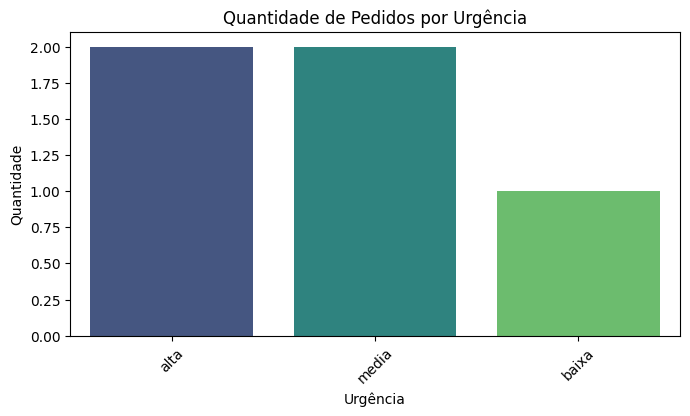

/tmp/ipykernel_2706/3418435574.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=valor_cidade, x='cidade_destino', y='valor_unitario', palette='pastel')


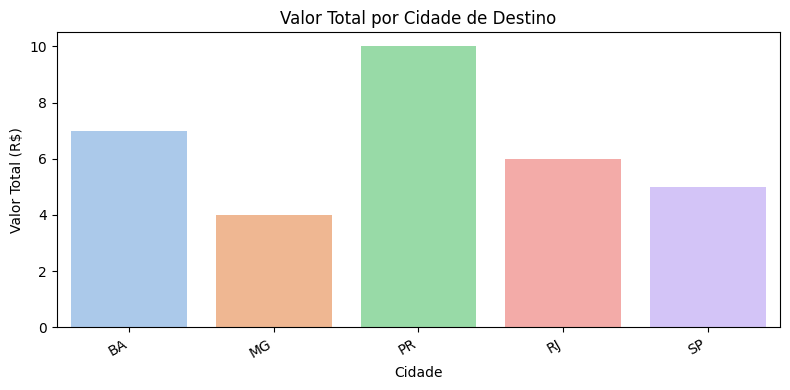

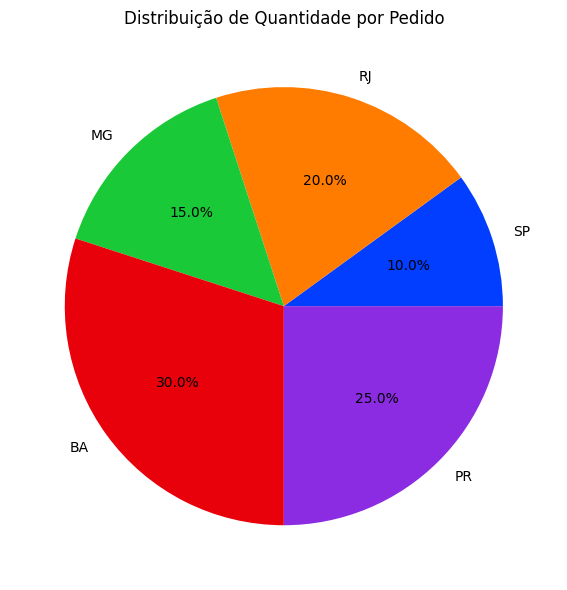

In [7]:
from pprint import pprint
from collections import deque
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. CARREGAMENTO DOS DADOS
# Lê o CSV e converte cada linha em uma TUPLA imutável
# representando um pedido: (id, cidade, produto, categoria,
# quantidade, valor_unitario, urgencia, tempo, modal, pagamento)
# Big O: O(n) — percorre todas as n linhas do CSV uma vez
# ------------------------------------------------------------
df = pd.read_csv("Check_point_1_dados_logistica_RA_final_par.csv")
print("=== DataFrame Original ===")
print(df)

# Converte cada linha do DataFrame em uma tupla imutável
# Tuplas são usadas aqui pois os dados do pedido não devem ser alterados
pedidos_tuplas = [tuple(row) for row in df.itertuples(index=False, name=None)]

# Mapeamento das colunas para facilitar acesso por índice
# (pedido_id, cidade_destino, produto, categoria, quantidade,
#  valor_unitario, urgencia, tempo_estimado_horas, modal, status_pagamento)
URGENCIA_IDX = 6  # índice da urgência dentro da tupla

print("\n=== Pedidos como Tuplas ===")
pprint(pedidos_tuplas)


# ------------------------------------------------------------
# 2. ORDENAÇÃO DOS PEDIDOS
# Ordena os pedidos pelo valor unitário (crescente)
# Big O: O(n log n) — algoritmo Timsort do Python
# ------------------------------------------------------------
pedidos_ordenados = sorted(pedidos_tuplas, key=lambda x: x[5])  # índice 5 = valor_unitario
print("\n=== Pedidos Ordenados por Valor Unitário ===")
pprint(pedidos_ordenados)


# ------------------------------------------------------------
# 3. ORGANIZAÇÃO DA FILA POR URGÊNCIA (RECURSÃO + DEQUE)
# Pedidos "alta" vão para o início da fila (appendleft)
# Pedidos "media" e "baixa" vão para o final (append)
# Big O: O(n) — cada pedido é processado uma única vez
# Espaço: O(n) — pilha de recursão cresce n vezes
# ------------------------------------------------------------
def organizar_fila(pedidos, fila):
    """
    Função recursiva que organiza pedidos em uma deque por urgência.

    """
    # Caso base: sem pedidos para processar
    if len(pedidos) == 0:
        return fila

    item = pedidos[0]  # pega o primeiro pedido da lista

    # Pedidos de alta urgência têm prioridade — vão para o início
    if item[URGENCIA_IDX] == "alta":
        fila.appendleft(item)  # O(1) — inserção no início da deque
    else:
        fila.append(item)      # O(1) — inserção no final da deque

    # Chamada recursiva com o restante da lista (sem o primeiro item)
    return organizar_fila(pedidos[1:], fila)


fila = deque()  # estrutura deque: eficiente para inserção em ambas as pontas
resultado = organizar_fila(pedidos_tuplas, fila)

print("\n=== Fila Organizada por Urgência ===")
pprint(resultado)


# ------------------------------------------------------------
# 4. GERAÇÃO DE GRÁFICOS
# Visualizações para análise dos dados logísticos
# Big O: O(n) para montagem dos dados em cada gráfico
# ------------------------------------------------------------

# Gráfico 1 — Quantidade de pedidos por urgência (barras)
urgencia_count = df['urgencia'].value_counts().reset_index()
urgencia_count.columns = ['urgencia', 'quantidade']

plt.figure(figsize=(7, 4))
sns.barplot(data=urgencia_count, x='urgencia', y='quantidade', palette='viridis')
plt.title('Quantidade de Pedidos por Urgência')
plt.xlabel('Urgência')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# Gráfico 2 — Valor total por cidade de destino (barras)
valor_cidade = df.groupby('cidade_destino')['valor_unitario'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=valor_cidade, x='cidade_destino', y='valor_unitario', palette='pastel')
plt.title('Valor Total por Cidade de Destino')
plt.xlabel('Cidade')
plt.ylabel('Valor Total (R$)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Gráfico 3 — Distribuição de quantidade por pedido (pizza)
plt.figure(figsize=(6, 6))
plt.pie(
    df['quantidade'],
    labels=df['cidade_destino'],
    autopct='%1.1f%%',
    colors=sns.color_palette('bright', len(df))
)
plt.title('Distribuição de Quantidade por Pedido')
plt.tight_layout()
plt.show()